In [35]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
import random 

In [36]:
#reading the words
words = open('names.txt', 'r').read().splitlines()
print(words[:5])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia']
32033


In [37]:
# Vocabulary of characters 
chars = sorted(list(set(''.join(words))))
stoi = {string: index+1 for index, string in enumerate(chars)} 
stoi['.'] = 0
itos = {index: string for string, index in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size) 

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [38]:
# Dataset: building and splitting 

block_size = 3 # context length 

def build_dataset(words):
    X, Y = [], []
    for w in words: 
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]


    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:n1]) # 80% of the data into the training set
Xdev, Ydev = build_dataset(words[n1:n2]) # 10% validation set
Xtest, Ytest = build_dataset(words[n2:]) # 10% test set 

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [44]:
# MLP revisited with no hardcoded parameters
n_emb = 10  # dimensionality of the character embedding vectors
n_hidden = 100 #neurons in the hidden layer 


g = torch.Generator().manual_seed(25) # for reproducibility 
C = torch.randn((vocab_size, n_emb), generator= g)

W1 = torch.rand((n_emb * block_size, n_hidden),  generator= g)
b1 = torch.rand(n_hidden, generator= g)
W2 = torch.randn((n_hidden, vocab_size), generator= g) * 0.1
b2 = torch.randn(vocab_size,  generator=g) * 0 # the 0 multiplication ensure that bias is 0 at first initialisation

parameters = [C, W1, b1, W2, b2]
print('Total parameters:',sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

Total parameters: 6097


In [45]:
# same optimization as last item
max_steps = 200000
batch_size = 32
loss_i = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0, Xtrain.shape[0], (batch_size,), generator=g)
    Xbatch, Ybatch = Xtrain[ix], Ytrain[ix]

    # forward pass
    emb = C[Xbatch] # embedding characters into vectors 
    embcat = emb.view(emb.shape[0], -1) #concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) #hidden layer 
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ybatch) #loss function

    #backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    # update 
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats 
    if i % 10000 == 0: # print every once in a while 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    loss_i.append(loss.log().item())


      0/ 200000: 3.4176
  10000/ 200000: 2.0711
  20000/ 200000: 2.5120
  30000/ 200000: 1.8929
  40000/ 200000: 2.0763
  50000/ 200000: 1.7958
  60000/ 200000: 2.2858
  70000/ 200000: 2.5357
  80000/ 200000: 2.0964
  90000/ 200000: 2.4008
 100000/ 200000: 2.2233
 110000/ 200000: 1.8981
 120000/ 200000: 2.1945
 130000/ 200000: 1.9138
 140000/ 200000: 1.8529
 150000/ 200000: 2.2802
 160000/ 200000: 1.9407
 170000/ 200000: 1.8955
 180000/ 200000: 2.4558
 190000/ 200000: 2.2886


The first iteration has a high loss (0/ 200000: 16.6016). This suggest that the logits at the very first itertaion are different from each other and the estimate is highly inaccurate. To avoid that, b2 is set to 0 for the first iteration and W2 is scaled.

Below it's possible to observe the effect of the activation function tanh, which converts the inputs into the range [-1,1].

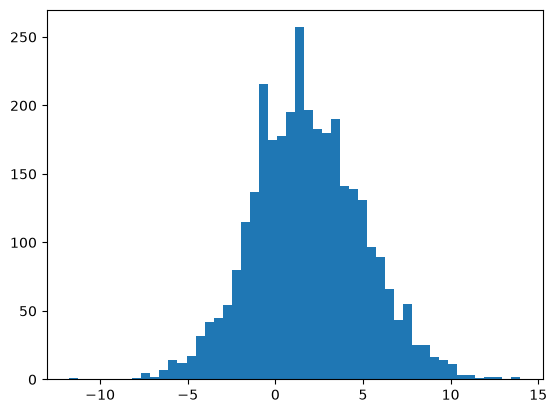

In [50]:
plt.hist(hpreact.view(-1).tolist(),50);


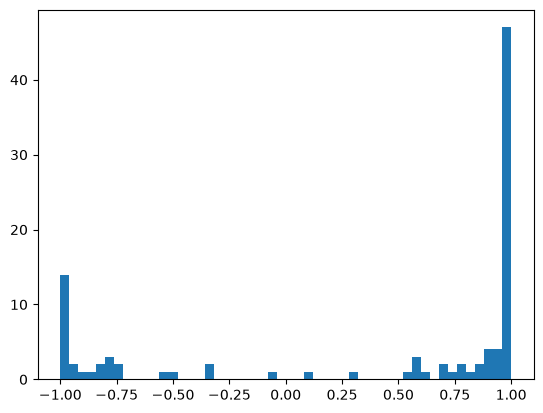

In [49]:
plt.hist(h.view(-1).tolist(),50);

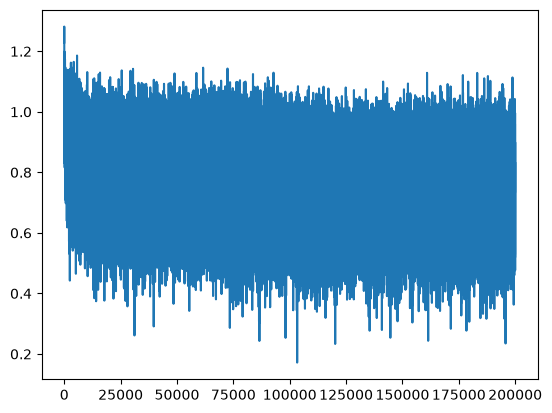

In [46]:
plt.plot(loss_i)

The chart avoid the 'hockey stick' shape and the performance improves. This happens becuase the NN is already optimising parameters from the very beginning (thank too smart initialisation) instead of squashing weights for the first few epochs.

In [47]:
@torch.no_grad() #decorator used to disable gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtrain, Ytrain),
        'dev': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]
    emb = C[x] # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1) #concat into (N, block_size * n_emb)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.100478172302246
dev 2.1426169872283936


In [48]:
# sampling from the model 
g = torch.Generator().manual_seed(25 +10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]  # (1, block_size, n_embed)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples= 1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

liomelle.
coidetchela.
cawsyk.
dae.
kailenichammali.
chrinthiya.
jaybinnarishnelys.
asmyte.
berley.
roralleah.
sha.
gen.
jocy.
daran.
shie.
aharleia.
lan.
juna.
astana.
ziveanna.
